# 🔥 연속 프레임 필터 효과 검증 — Before/After 비교 테스트 (v2)

## 목적
- **Before**: 필터 없이 매 프레임 탐지 → 오탐 포함된 전체 탐지 횟수 확인
- **After**: 연속 N프레임 이상 탐지 시에만 알람 → 오탐 감소율 측정
- **오탐 이미지 저장**: 어떤 것을 오탐했는지 원본 + bbox 이미지로 눈에 보이게 확인
- **smoke / fire 분류**: 탐지된 객체가 연기인지 불인지 따로 분류

## 테스트 환경
| 항목 | 값 |
|------|----|---|
| 모델 | YOLOv8n (Fine-tuned) |
| GPU | RTX 4060 Ti 8GB (CUDA) |
| Threshold | 0.10 |
| 테스트 영상 | demo_20260305_180347_[서해안선]_광명역.mp4 |
| 연속 프레임 기준 | 5프레임 (조절 가능) |

## 산출물
| 산출물 | 설명 |
|--------|------|
| `원본/` 폴더 | 탐지 발생 시점의 원본 이미지 |
| `bbox/` 폴더 | 탐지 발생 시점의 바운딩박스 이미지 |
| `before_detections.csv` | Before 전체 탐지 기록 (프레임, 시간, 클래스) |
| `after_alarms.csv` | After 알람 기록 |
| `filter_summary.json` | Before/After 비교 요약 |
| `temporal_filter_timeline.png` | 타임라인 비교 그래프 |
| `frame_threshold_comparison.png` | 프레임 수별 비교 그래프 |


In [4]:
# =============================================================================
# 셀 1: 라이브러리 import
# =============================================================================

from ultralytics import YOLO          # YOLOv8 모델 로드 및 추론
import cv2                            # OpenCV — 영상/이미지 처리
from pathlib import Path              # 파일 경로 처리
import numpy as np                    # 숫자 계산 (평균 등)
import time                           # 시간 측정
import json                           # JSON 파일 저장
import csv                            # CSV 파일 저장
import matplotlib.pyplot as plt       # 그래프 시각화
import matplotlib                     # matplotlib 설정

# 한글 폰트 설정 (그래프에서 한글 깨짐 방지)
matplotlib.rcParams["font.family"] = "Malgun Gothic"   # 윈도우 한글 폰트
matplotlib.rcParams["axes.unicode_minus"] = False       # 마이너스 깨짐 방지

print("✅ 라이브러리 로드 완료!")


✅ 라이브러리 로드 완료!


In [13]:
# =============================================================================
# 셀 2: 설정값 
# =============================================================================

# 프로젝트 루트 경로
PROJECT_ROOT = Path(r"N:\개인\이수빈\3.13_Mini_Project")

# 모델 경로 (Fine-tuned YOLOv8n)
MODEL_PATH = PROJECT_ROOT / "results" / "yolov8n_tuned" / "weights" / "best.pt"

# 테스트 영상 경로
VIDEO_PATH = PROJECT_ROOT / "DATASET" / "테스트영상" / "2.mp4"

# 신뢰도 임계값
CONF_THRESHOLD = 0.10                 # YOLO 탐지 기준 (10% 이상이면 탐지)

# ★★★ 연속 프레임 기준 ★★★
# 여기서 연속 프레임 수 조절 가능
# 10프레임으로 바꾸고 싶으면: CONSECUTIVE_FRAMES = 10
CONSECUTIVE_FRAMES = 10                # 이 숫자만 바꾸면 됨!

# GPU 설정
DEVICE="cpu"                          # 0 = 첫 번째 GPU (RTX 4060 Ti)

# ★ 이미지 저장 경로 (오탐 확인용)
SAVE_ROOT = PROJECT_ROOT / "results" / "temporal_filter_test"
SAVE_ORIG = SAVE_ROOT / "원본"         # 원본 이미지 저장 폴더
SAVE_BBOX = SAVE_ROOT / "bbox"         # bbox 이미지 저장 폴더

# 폴더 자동 생성
SAVE_ROOT.mkdir(parents=True, exist_ok=True)   # 상위 폴더 생성
SAVE_ORIG.mkdir(parents=True, exist_ok=True)   # 원본 폴더 생성
SAVE_BBOX.mkdir(parents=True, exist_ok=True)   # bbox 폴더 생성

# ★ 이미지 저장 간격 (프레임 단위)
# 모든 탐지 프레임을 다 저장하면 수천 장이 되므로,
# "탐지 이벤트 시작 시점"만 저장합니다
SAVE_EVERY_EVENT = True               # True = 이벤트 시작 시점만 저장

# 설정 확인 출력
print(f"📁 프로젝트 경로: {PROJECT_ROOT}")
print(f"🧠 모델 경로: {MODEL_PATH}")
print(f"🎬 영상 경로: {VIDEO_PATH}")
print(f"🎯 Threshold: {CONF_THRESHOLD}")
print(f"🔢 연속 프레임 기준: {CONSECUTIVE_FRAMES}")
print(f"🖥️ GPU: {DEVICE}")
print(f"📸 이미지 저장 경로: {SAVE_ROOT}")


📁 프로젝트 경로: N:\개인\이수빈\3.13_Mini_Project
🧠 모델 경로: N:\개인\이수빈\3.13_Mini_Project\results\yolov8n_tuned\weights\best.pt
🎬 영상 경로: N:\개인\이수빈\3.13_Mini_Project\DATASET\테스트영상\2.mp4
🎯 Threshold: 0.1
🔢 연속 프레임 기준: 10
🖥️ GPU: cpu
📸 이미지 저장 경로: N:\개인\이수빈\3.13_Mini_Project\results\temporal_filter_test


In [14]:
# =============================================================================
# 셀 3: 모델 로드 + 클래스 확인
# =============================================================================

print("📦 모델 로드 중...")
model = YOLO(str(MODEL_PATH))                       # YOLO 모델 로드
print(f"✅ 모델 로드 완료: {MODEL_PATH.name}")

# ★ 모델의 클래스 목록 확인 (smoke, fire 등)
class_names = model.names                            # {0: "fire", 1: "smoke"} 같은 딕셔너리
print(f"\n📋 모델 클래스 목록:")
for idx, name in class_names.items():                # 클래스 번호와 이름 출력
    print(f"   {idx}: {name}")                       # 예: 0: fire, 1: smoke

# 클래스 인덱스 저장 (나중에 분류용)
# ※ 모델마다 순서가 다를 수 있으니 여기서 확인!
print(f"\n→ 이 정보를 보고 아래 코드에서 클래스별 분류가 진행됩니다")


📦 모델 로드 중...
✅ 모델 로드 완료: best.pt

📋 모델 클래스 목록:
   0: fire
   1: smoke

→ 이 정보를 보고 아래 코드에서 클래스별 분류가 진행됩니다


In [15]:
# =============================================================================
# 셀 4: 영상 정보 확인
# =============================================================================

cap = cv2.VideoCapture(str(VIDEO_PATH))             # 영상 파일 열기

if not cap.isOpened():                              # 열기 실패
    print("❌ 영상 파일을 열 수 없습니다!")
    print(f"   경로 확인: {VIDEO_PATH}")
else:                                               # 열기 성공
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))   # 너비
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)) # 높이
    fps = cap.get(cv2.CAP_PROP_FPS)                  # FPS
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))  # 총 프레임
    duration = total_frames / fps if fps > 0 else 0  # 길이(초)

    print(f"📹 영상 정보:")
    print(f"   해상도: {width}x{height}")
    print(f"   FPS: {fps:.1f}")
    print(f"   총 프레임 수: {total_frames:,}")
    print(f"   영상 길이: {duration:.1f}초 ({duration/60:.1f}분)")

cap.release()                                       # 영상 닫기


📹 영상 정보:
   해상도: 1920x1080
   FPS: 30.0
   총 프레임 수: 37,434
   영상 길이: 1247.8초 (20.8분)


## 🔵 Before 테스트 — 필터 없음

**이번에 추가된 것들:**
- 탐지 발생 시 **원본 이미지** + **bbox 이미지** 저장 → 뭘 오탐했는지 눈으로 확인 가능
- 각 탐지마다 **smoke / fire 분류** → 어떤 클래스가 탐지됐는지 기록
- 모든 탐지를 **CSV 파일**로 저장 → 엑셀에서 열어서 분석 가능


In [16]:
# =============================================================================
# 셀 5: Before 테스트 — 필터 없이 모든 탐지 기록 + 이미지 저장 + 분류
# =============================================================================

print("=" * 60)
print("🔵 Before 테스트 시작 (필터 없음)")
print("   → 탐지 시 원본/bbox 이미지 저장 + smoke/fire 분류")
print("=" * 60)

cap = cv2.VideoCapture(str(VIDEO_PATH))             # 영상 열기
fps = cap.get(cv2.CAP_PROP_FPS)                     # FPS
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))  # 총 프레임

# 결과 저장용
before_detections = []       # 탐지 정보 리스트 (프레임, 시간, 클래스 등)
before_frame_results = []    # 매 프레임 탐지 여부 [True, False, ...]
before_frame_classes = []    # 매 프레임 탐지된 클래스 목록 [[], ["fire"], ["smoke","fire"], ...]

# ★ 이미지 저장 관련
in_event = False             # 현재 탐지 이벤트 진행 중인지 (이벤트 시작 시점만 저장하기 위해)
saved_count = 0              # 저장한 이미지 수

# 통계
total_fire = 0               # fire 탐지 프레임 수
total_smoke = 0              # smoke 탐지 프레임 수
total_both = 0               # fire+smoke 동시 탐지 프레임 수

frame_idx = 0                # 프레임 번호
start_time = time.time()     # 시작 시각

while True:
    ret, frame = cap.read()                         # 프레임 읽기
    if not ret:                                     # 영상 끝
        break

    # YOLO 추론
    results = model.predict(
        frame,                                      # 입력 이미지
        conf=CONF_THRESHOLD,                        # 신뢰도 기준
        imgsz=640,                                  # 입력 크기
        device=DEVICE,                              # GPU
        verbose=False                               # 로그 끄기
    )

    # 탐지 결과 분석
    boxes = results[0].boxes                        # 바운딩박스 객체
    num_boxes = len(boxes)                          # 박스 수
    detected = num_boxes > 0                        # 탐지 여부

    # ★ 클래스별 분류
    frame_classes = []                              # 이 프레임에서 탐지된 클래스들
    class_details = []                              # 상세 정보 (클래스명, 신뢰도)

    if detected:                                    # 탐지가 있으면
        for box in boxes:                           # 각 바운딩박스마다
            cls_id = int(box.cls[0])                # 클래스 번호 (0, 1, ...)
            cls_name = class_names[cls_id]          # 클래스 이름 ("fire", "smoke")
            conf = float(box.conf[0])               # 신뢰도 (0.0~1.0)
            frame_classes.append(cls_name)          # 클래스 이름 추가
            class_details.append({                  # 상세 정보 저장
                "class": cls_name,                  # 클래스명
                "confidence": round(conf, 4),       # 신뢰도 (소수점 4자리)
                "bbox": box.xyxy[0].tolist()        # 좌표 [x1,y1,x2,y2]
            })

        # 통계 업데이트
        unique_classes = set(frame_classes)         # 중복 제거
        has_fire = "fire" in unique_classes         # fire 포함 여부
        has_smoke = "smoke" in unique_classes       # smoke 포함 여부
        if has_fire:
            total_fire += 1                         # fire 카운트
        if has_smoke:
            total_smoke += 1                        # smoke 카운트
        if has_fire and has_smoke:
            total_both += 1                         # 동시 탐지 카운트

    before_frame_results.append(detected)           # 탐지 여부 저장
    before_frame_classes.append(frame_classes)      # 클래스 목록 저장

    # ★ 이미지 저장 (탐지 이벤트 시작 시점만)
    if detected and not in_event:                   # 새로운 탐지 이벤트 시작!
        in_event = True                             # 이벤트 진행 중 표시
        saved_count += 1

        # 시간 정보
        time_sec = frame_idx / fps if fps > 0 else 0
        minutes = int(time_sec // 60)               # 분
        seconds = time_sec % 60                     # 초

        # 파일명: 이벤트번호_프레임번호_시간_클래스
        cls_str = "+".join(sorted(set(frame_classes)))  # "fire", "smoke", "fire+smoke"
        fname = f"evt{saved_count:03d}_f{frame_idx:06d}_{minutes:02d}m{seconds:04.1f}s_{cls_str}"

        # 원본 이미지 저장
        orig_path = SAVE_ORIG / f"{fname}.jpg"
        cv2.imwrite(str(orig_path), frame)          # 원본 저장

        # bbox 이미지 저장
        bbox_frame = results[0].plot()               # YOLO가 bbox 그려줌
        bbox_path = SAVE_BBOX / f"{fname}.jpg"
        cv2.imwrite(str(bbox_path), bbox_frame)      # bbox 저장

    elif not detected:                              # 탐지 안 되면
        in_event = False                            # 이벤트 종료

    # 탐지 기록 저장
    if detected:
        time_sec = frame_idx / fps if fps > 0 else 0
        before_detections.append({
            "frame": frame_idx,                     # 프레임 번호
            "time_sec": round(time_sec, 2),         # 시간(초)
            "num_boxes": num_boxes,                  # 박스 수
            "classes": frame_classes.copy(),         # 탐지된 클래스 목록
            "class_str": "+".join(sorted(set(frame_classes))),  # 문자열
            "details": class_details.copy()         # 상세 정보
        })

    frame_idx += 1

    # 진행률 (500프레임마다)
    if frame_idx % 500 == 0:
        progress = frame_idx / total_frames * 100
        print(f"   진행: {frame_idx:,}/{total_frames:,} ({progress:.1f}%) | 저장 이미지: {saved_count}장")

cap.release()                                       # 영상 닫기
elapsed = time.time() - start_time

# ★ CSV 저장 (Before 전체 탐지 기록)
csv_path = SAVE_ROOT / "before_detections.csv"
with open(csv_path, "w", newline="", encoding="utf-8-sig") as f:
    writer = csv.writer(f)
    writer.writerow(["프레임", "시간(초)", "박스수", "클래스", "이미지파일"])
    for det in before_detections:
        writer.writerow([
            det["frame"],
            det["time_sec"],
            det["num_boxes"],
            det["class_str"],
            f"evt???_f{det['frame']:06d}"
        ])

# 결과 출력
print(f"\n📊 Before 결과:")
print(f"   총 프레임: {frame_idx:,}")
print(f"   탐지 프레임: {len(before_detections):,}")
print(f"   소요 시간: {elapsed:.1f}초")
print(f"\n   📸 저장된 이미지: {saved_count}세트 (원본+bbox)")
print(f"   📁 원본 폴더: {SAVE_ORIG}")
print(f"   📁 bbox 폴더: {SAVE_BBOX}")
print(f"   📁 CSV 파일: {csv_path}")

# ★ 클래스별 통계
print(f"\n   🔥 fire 탐지 프레임: {total_fire:,}개")
print(f"   💨 smoke 탐지 프레임: {total_smoke:,}개")
print(f"   🔥💨 동시 탐지 프레임: {total_both:,}개")

# 탐지 시점 (처음 10개)
if before_detections:
    print(f"\n   탐지 시점 (처음 10개):")
    for det in before_detections[:10]:
        print(f"     프레임 {det['frame']:>6} | {det['time_sec']:>8.2f}초 | 박스 {det['num_boxes']}개 | {det['class_str']}")
    if len(before_detections) > 10:
        print(f"     ... 외 {len(before_detections) - 10}건")


🔵 Before 테스트 시작 (필터 없음)
   → 탐지 시 원본/bbox 이미지 저장 + smoke/fire 분류
   진행: 500/37,434 (1.3%) | 저장 이미지: 0장
   진행: 1,000/37,434 (2.7%) | 저장 이미지: 5장
   진행: 1,500/37,434 (4.0%) | 저장 이미지: 7장
   진행: 2,000/37,434 (5.3%) | 저장 이미지: 8장
   진행: 2,500/37,434 (6.7%) | 저장 이미지: 11장
   진행: 3,000/37,434 (8.0%) | 저장 이미지: 12장
   진행: 3,500/37,434 (9.3%) | 저장 이미지: 17장
   진행: 4,000/37,434 (10.7%) | 저장 이미지: 19장
   진행: 4,500/37,434 (12.0%) | 저장 이미지: 21장
   진행: 5,000/37,434 (13.4%) | 저장 이미지: 21장
   진행: 5,500/37,434 (14.7%) | 저장 이미지: 23장
   진행: 6,000/37,434 (16.0%) | 저장 이미지: 23장
   진행: 6,500/37,434 (17.4%) | 저장 이미지: 24장
   진행: 7,000/37,434 (18.7%) | 저장 이미지: 25장
   진행: 7,500/37,434 (20.0%) | 저장 이미지: 26장
   진행: 8,000/37,434 (21.4%) | 저장 이미지: 27장
   진행: 8,500/37,434 (22.7%) | 저장 이미지: 28장
   진행: 9,000/37,434 (24.0%) | 저장 이미지: 28장
   진행: 9,500/37,434 (25.4%) | 저장 이미지: 31장
   진행: 10,000/37,434 (26.7%) | 저장 이미지: 31장
   진행: 10,500/37,434 (28.0%) | 저장 이미지: 31장
   진행: 11,000/37,434 (29.4%) | 저장 이미지: 32장
   진행: 11,500/37,434 

📸 저장된 이미지: 원본 134장, bbox 134장


C:\Users\User\AppData\Local\Temp\ipykernel_24500\995084466.py:38: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_24500\995084466.py:39: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Malgun Gothic.
  plt.savefig(str(SAVE_ROOT / "detection_preview.png"),
c:\Users\User\.conda\envs\DL\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


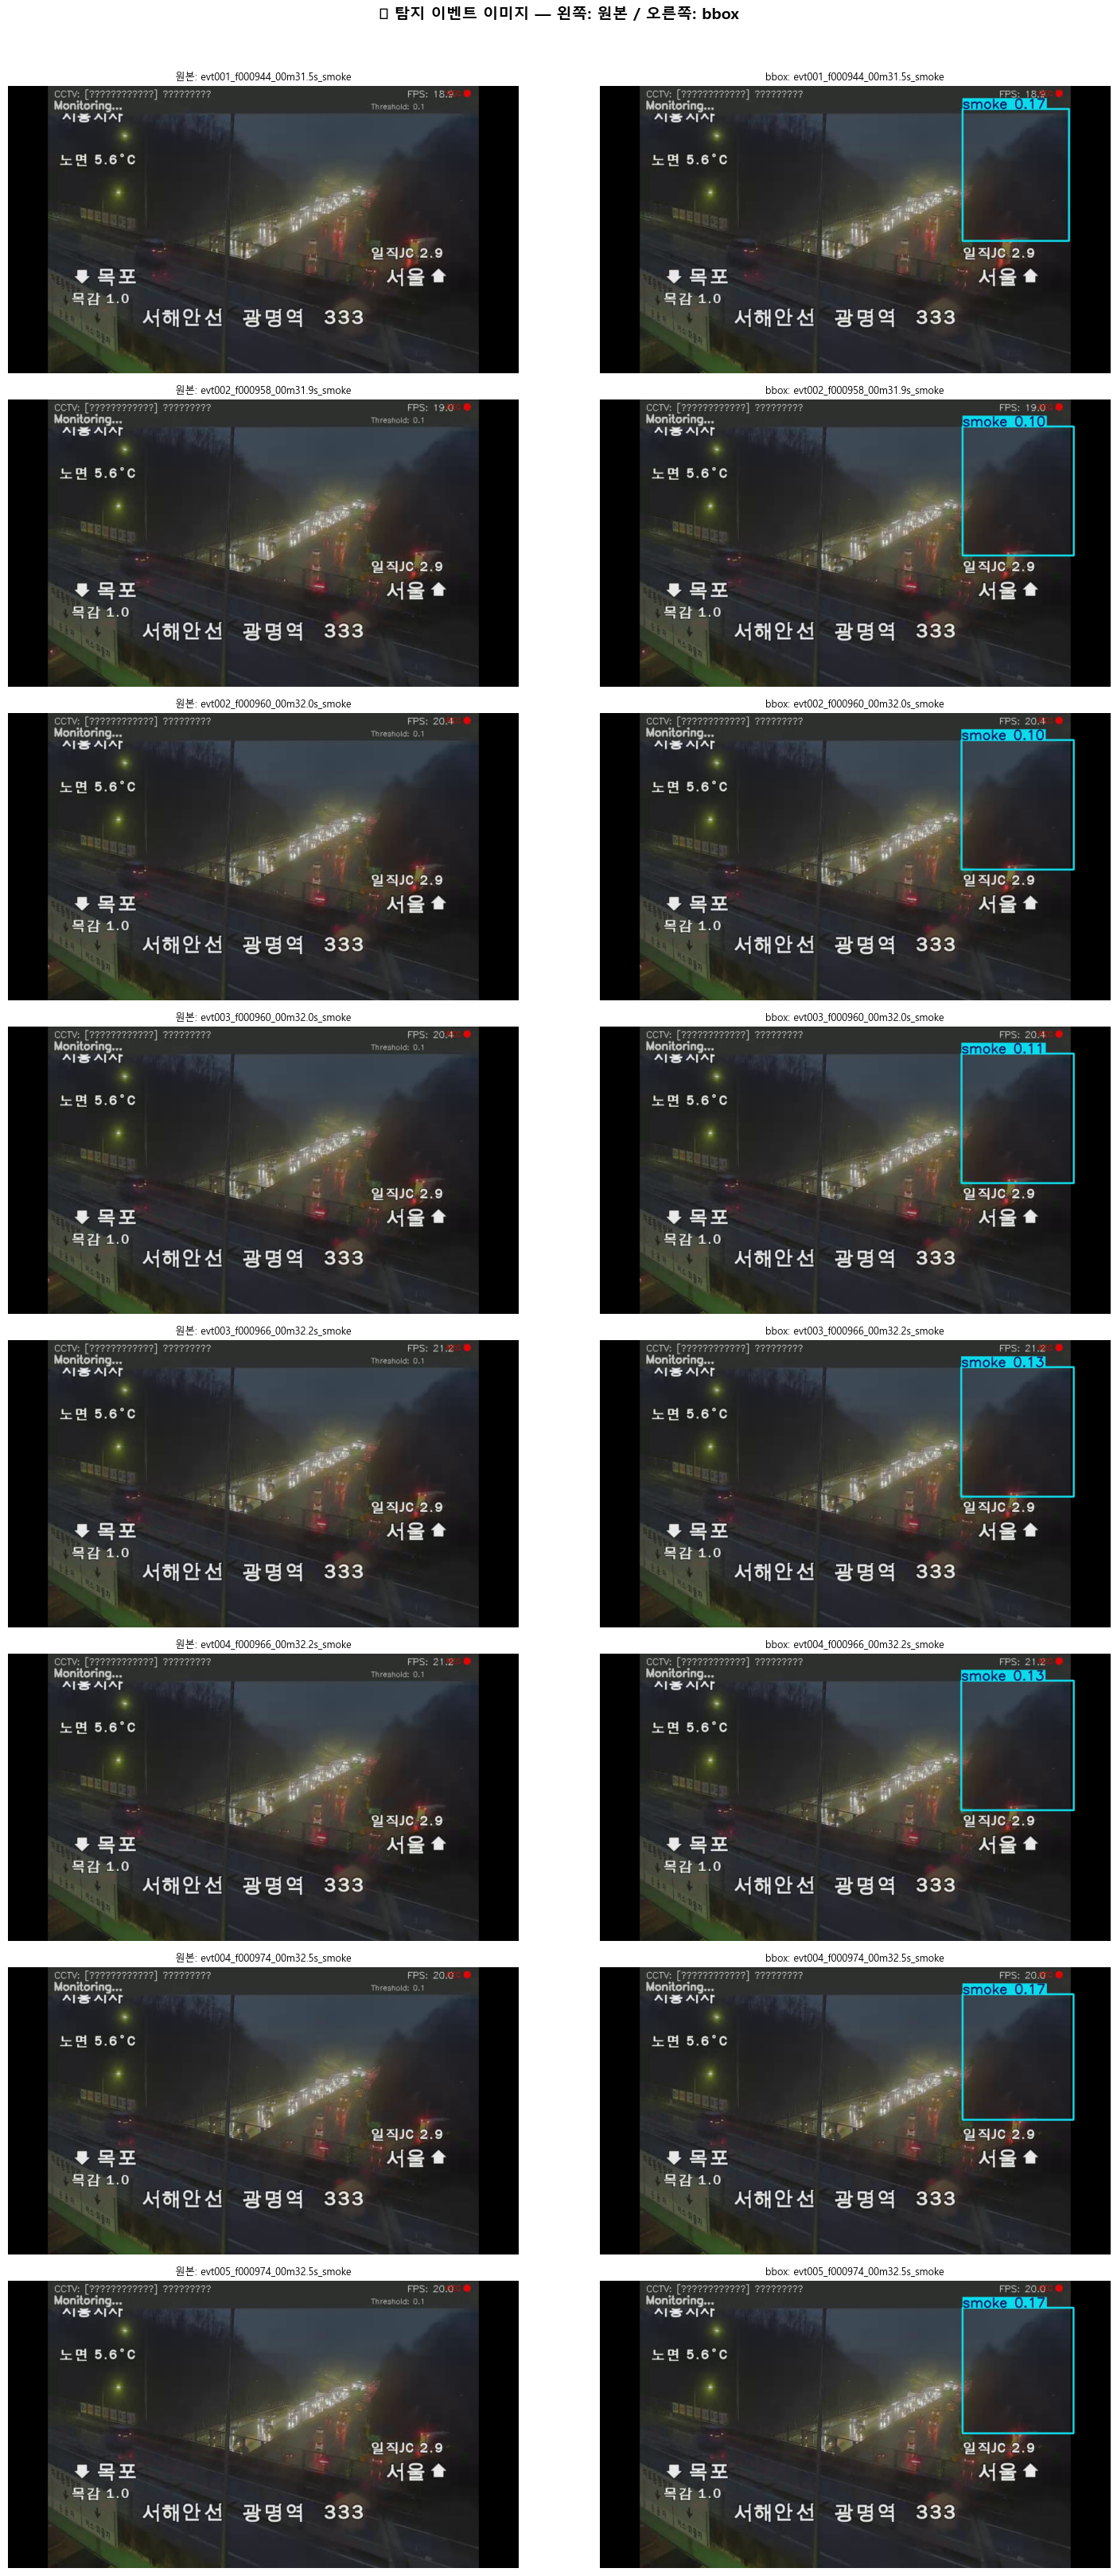


💾 미리보기 저장: N:\개인\이수빈\3.13_Mini_Project\results\temporal_filter_test\detection_preview.png


In [17]:
# =============================================================================
# 셀 6: 저장된 이미지 미리보기 (처음 8개)
# =============================================================================

# 저장된 bbox 이미지 목록 가져오기
bbox_images = sorted(SAVE_BBOX.glob("*.jpg"))       # bbox 폴더의 모든 jpg
orig_images = sorted(SAVE_ORIG.glob("*.jpg"))       # 원본 폴더의 모든 jpg

print(f"📸 저장된 이미지: 원본 {len(orig_images)}장, bbox {len(bbox_images)}장")

# 미리보기 (최대 8개, 원본+bbox 쌍으로)
show_count = min(8, len(bbox_images))               # 최대 8개까지

if show_count > 0:
    fig, axes = plt.subplots(show_count, 2,          # N행 2열
                             figsize=(16, 4 * show_count))  # 크기

    if show_count == 1:                              # 1개일 때 axes 형태 맞추기
        axes = [axes]

    for i in range(show_count):
        # 원본 이미지
        orig_img = cv2.imread(str(orig_images[i]))   # 이미지 읽기
        orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)  # BGR→RGB 변환
        axes[i][0].imshow(orig_img)                  # 원본 표시
        axes[i][0].set_title(f"원본: {orig_images[i].stem}", fontsize=9)
        axes[i][0].axis("off")                      # 축 숨기기

        # bbox 이미지
        bbox_img = cv2.imread(str(bbox_images[i]))   # 이미지 읽기
        bbox_img = cv2.cvtColor(bbox_img, cv2.COLOR_BGR2RGB)  # BGR→RGB 변환
        axes[i][1].imshow(bbox_img)                  # bbox 표시
        axes[i][1].set_title(f"bbox: {bbox_images[i].stem}", fontsize=9)
        axes[i][1].axis("off")                      # 축 숨기기

    plt.suptitle("🔍 탐지 이벤트 이미지 — 왼쪽: 원본 / 오른쪽: bbox",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(str(SAVE_ROOT / "detection_preview.png"),
                dpi=120, bbox_inches="tight")
    plt.show()
    print(f"\n💾 미리보기 저장: {SAVE_ROOT / 'detection_preview.png'}")
else:
    print("ℹ️ 저장된 이미지가 없습니다")


🔥💨 클래스별 탐지 분석

📊 전체 탐지 프레임: 218개
   🔥 fire 포함: 144개 (66.1%)
   💨 smoke 포함: 74개 (33.9%)

📊 연속 10프레임 필터 적용 시 (클래스별):
   🔥 fire 알람: 2회
      프레임   4381 |   146.03초
      프레임   4465 |   148.83초
   💨 smoke 알람: 2회
      프레임   8471 |   282.37초
      프레임   9253 |   308.43초


C:\Users\User\AppData\Local\Temp\ipykernel_24500\2486439504.py:122: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_24500\2486439504.py:122: UserWarning: Glyph 128168 (\N{DASH SYMBOL}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_24500\2486439504.py:123: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Malgun Gothic.
  plt.savefig(str(SAVE_ROOT / "class_distribution.png"), dpi=150, bbox_inches="tight")
C:\Users\User\AppData\Local\Temp\ipykernel_24500\2486439504.py:123: UserWarning: Glyph 128168 (\N{DASH SYMBOL}) missing from font(s) Malgun Gothic.
  plt.savefig(str(SAVE_ROOT / "class_distribution.png"), dpi=150, bbox_inches="tight")
c:\Users\User\.conda\envs\DL\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Use

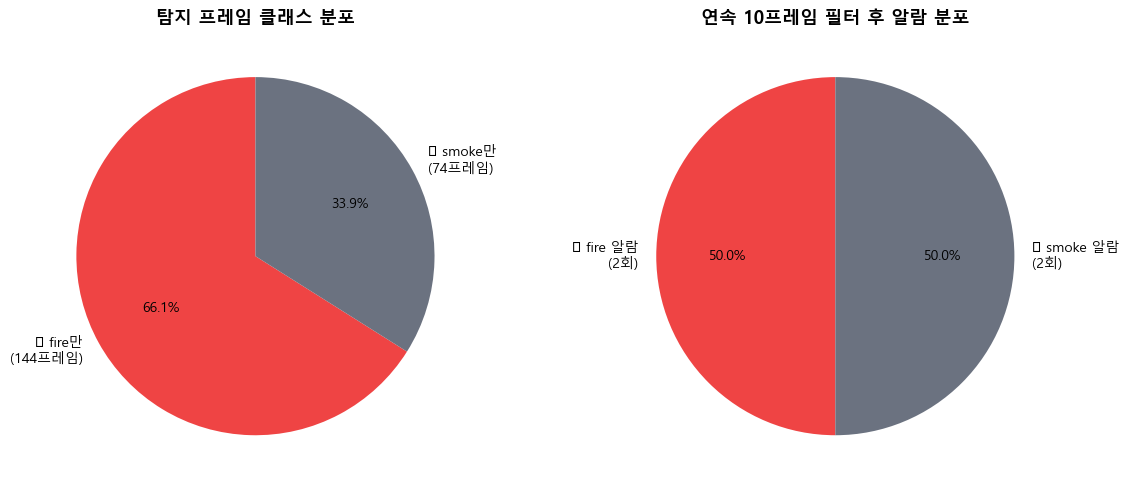


💾 그래프 저장: N:\개인\이수빈\3.13_Mini_Project\results\temporal_filter_test\class_distribution.png


In [18]:
# =============================================================================
# 셀 7: 클래스별 상세 분석 — smoke vs fire
# =============================================================================

print("=" * 60)
print("🔥💨 클래스별 탐지 분석")
print("=" * 60)

# 클래스별 탐지 프레임 분리
fire_frames = []             # fire가 탐지된 프레임 목록
smoke_frames = []            # smoke가 탐지된 프레임 목록

for det in before_detections:                       # 모든 탐지 기록 순회
    if "fire" in det["classes"]:                    # fire 포함
        fire_frames.append(det["frame"])
    if "smoke" in det["classes"]:                   # smoke 포함
        smoke_frames.append(det["frame"])

print(f"\n📊 전체 탐지 프레임: {len(before_detections):,}개")
print(f"   🔥 fire 포함: {len(fire_frames):,}개 ({len(fire_frames)/len(before_detections)*100:.1f}%)")
print(f"   💨 smoke 포함: {len(smoke_frames):,}개 ({len(smoke_frames)/len(before_detections)*100:.1f}%)")

# ★ 클래스별 연속 프레임 분석
def count_consecutive_events(frame_results, class_filter, all_classes, threshold):
    """특정 클래스의 연속 프레임 이벤트 수를 세는 함수"""
    count = 0              # 연속 카운터
    active = False         # 알람 활성 여부
    events = 0             # 이벤트 수
    event_list = []        # 이벤트 목록

    for i, (detected, classes) in enumerate(zip(frame_results, all_classes)):
        # 해당 클래스가 이 프레임에서 탐지됐는지
        class_detected = detected and (class_filter in classes)

        if class_detected:
            count += 1
        else:
            count = 0
            active = False

        if count >= threshold and not active:
            active = True
            events += 1
            time_sec = i / fps if fps > 0 else 0
            event_list.append({"frame": i, "time_sec": round(time_sec, 2)})

    return events, event_list

# fire만으로 연속 5프레임 필터
fire_events, fire_event_list = count_consecutive_events(
    before_frame_results, "fire", before_frame_classes, CONSECUTIVE_FRAMES)

# smoke만으로 연속 5프레임 필터
smoke_events, smoke_event_list = count_consecutive_events(
    before_frame_results, "smoke", before_frame_classes, CONSECUTIVE_FRAMES)

print(f"\n📊 연속 {CONSECUTIVE_FRAMES}프레임 필터 적용 시 (클래스별):")
print(f"   🔥 fire 알람: {fire_events}회")
if fire_event_list:
    for evt in fire_event_list[:5]:
        print(f"      프레임 {evt['frame']:>6} | {evt['time_sec']:>8.2f}초")
    if len(fire_event_list) > 5:
        print(f"      ... 외 {len(fire_event_list)-5}건")

print(f"   💨 smoke 알람: {smoke_events}회")
if smoke_event_list:
    for evt in smoke_event_list[:5]:
        print(f"      프레임 {evt['frame']:>6} | {evt['time_sec']:>8.2f}초")
    if len(smoke_event_list) > 5:
        print(f"      ... 외 {len(smoke_event_list)-5}건")

# ★ 클래스별 파이 차트
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 왼쪽: 탐지 프레임 비율
fire_only = total_fire - total_both                 # fire만
smoke_only = total_smoke - total_both               # smoke만
labels1 = []
sizes1 = []
colors1 = []
if fire_only > 0:
    labels1.append(f"🔥 fire만\n({fire_only:,}프레임)")
    sizes1.append(fire_only)
    colors1.append("#ef4444")
if smoke_only > 0:
    labels1.append(f"💨 smoke만\n({smoke_only:,}프레임)")
    sizes1.append(smoke_only)
    colors1.append("#6b7280")
if total_both > 0:
    labels1.append(f"🔥💨 동시\n({total_both:,}프레임)")
    sizes1.append(total_both)
    colors1.append("#f59e0b")

if sizes1:
    ax1.pie(sizes1, labels=labels1, colors=colors1,
            autopct="%1.1f%%", startangle=90, textprops={"fontsize": 10})
    ax1.set_title("탐지 프레임 클래스 분포", fontsize=13, fontweight="bold")
else:
    ax1.text(0.5, 0.5, "탐지 없음", ha="center", va="center")

# 오른쪽: 필터 적용 후 알람 비율
labels2 = []
sizes2 = []
colors2 = []
if fire_events > 0:
    labels2.append(f"🔥 fire 알람\n({fire_events}회)")
    sizes2.append(fire_events)
    colors2.append("#ef4444")
if smoke_events > 0:
    labels2.append(f"💨 smoke 알람\n({smoke_events}회)")
    sizes2.append(smoke_events)
    colors2.append("#6b7280")

if sizes2:
    ax2.pie(sizes2, labels=labels2, colors=colors2,
            autopct="%1.1f%%", startangle=90, textprops={"fontsize": 10})
    ax2.set_title(f"연속 {CONSECUTIVE_FRAMES}프레임 필터 후 알람 분포",
                  fontsize=13, fontweight="bold")
else:
    ax2.text(0.5, 0.5, "알람 없음", ha="center", va="center")

plt.tight_layout()
plt.savefig(str(SAVE_ROOT / "class_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"\n💾 그래프 저장: {SAVE_ROOT / 'class_distribution.png'}")


## 🟢 After 테스트 — 연속 프레임 필터 적용

**Before의 결과를 재사용**합니다 (영상을 다시 안 돌림 → 0초 소요)

**로직**: `before_frame_results` 리스트를 순회하면서 연속 N프레임 필터만 적용


In [19]:
# =============================================================================
# 셀 8: After 테스트 — 연속 프레임 필터 적용
# =============================================================================

print("=" * 60)
print(f"🟢 After 테스트 시작 (연속 {CONSECUTIVE_FRAMES}프레임 필터)")
print("=" * 60)

# ★ Before 결과를 재사용 (영상 다시 안 돌림!)
after_alarms = []            # 알람 목록
consecutive_count = 0        # 연속 카운터
alarm_active = False         # 알람 상태
alarm_id = 0                 # 알람 번호

for i, (detected, classes) in enumerate(
    zip(before_frame_results, before_frame_classes)):

    if detected:                                    # 탐지됐으면
        consecutive_count += 1                      # 카운터 +1
    else:                                           # 안 됐으면
        consecutive_count = 0                       # 리셋
        alarm_active = False

    # ★ 연속 N프레임 달성 → 알람!                     # 여기서 연속 프레임 수 조절 가능
    if consecutive_count >= CONSECUTIVE_FRAMES:      # 기준 도달
        if not alarm_active:                        # 새 알람
            alarm_active = True
            alarm_id += 1
            time_sec = i / fps if fps > 0 else 0
            after_alarms.append({
                "alarm_id": alarm_id,
                "start_frame": i,
                "time_sec": round(time_sec, 2),
                "consecutive": consecutive_count,
                "classes": classes.copy()           # ★ 알람 시점의 클래스도 기록
            })
            cls_str = "+".join(sorted(set(classes))) if classes else "none"
            print(f"   🚨 알람 #{alarm_id} | 프레임 {i} ({time_sec:.2f}초) | "
                  f"연속 {consecutive_count}프레임 | {cls_str}")

# ★ CSV 저장
csv_path = SAVE_ROOT / "after_alarms.csv"
with open(csv_path, "w", newline="", encoding="utf-8-sig") as f:
    writer = csv.writer(f)
    writer.writerow(["알람번호", "프레임", "시간(초)", "연속프레임수", "클래스"])
    for alarm in after_alarms:
        cls_str = "+".join(sorted(set(alarm["classes"]))) if alarm["classes"] else ""
        writer.writerow([
            alarm["alarm_id"],
            alarm["start_frame"],
            alarm["time_sec"],
            alarm["consecutive"],
            cls_str
        ])

print(f"\n📊 After 결과:")
print(f"   총 프레임: {len(before_frame_results):,}")
print(f"   알람 발생: {len(after_alarms)}회")
print(f"   📁 CSV: {csv_path}")


🟢 After 테스트 시작 (연속 10프레임 필터)
   🚨 알람 #1 | 프레임 4381 (146.03초) | 연속 10프레임 | fire
   🚨 알람 #2 | 프레임 4465 (148.83초) | 연속 10프레임 | fire
   🚨 알람 #3 | 프레임 8471 (282.37초) | 연속 10프레임 | smoke
   🚨 알람 #4 | 프레임 9253 (308.43초) | 연속 10프레임 | smoke

📊 After 결과:
   총 프레임: 37,434
   알람 발생: 4회
   📁 CSV: N:\개인\이수빈\3.13_Mini_Project\results\temporal_filter_test\after_alarms.csv


📁 After 원본 저장 경로: N:\개인\이수빈\3.13_Mini_Project\results\temporal_filter_test\after_원본
📁 After bbox 저장 경로: N:\개인\이수빈\3.13_Mini_Project\results\temporal_filter_test\after_bbox

🔍 저장할 알람 수: 4개
   ✅ 알람 #0001 | 프레임 4381 | 탐지 1개 | 저장 완료
   ✅ 알람 #0002 | 프레임 4465 | 탐지 1개 | 저장 완료
   ✅ 알람 #0003 | 프레임 8471 | 탐지 1개 | 저장 완료
   ✅ 알람 #0004 | 프레임 9253 | 탐지 1개 | 저장 완료

📊 After 이미지 저장 완료: 총 4장 (원본 + bbox)
   📁 원본: N:\개인\이수빈\3.13_Mini_Project\results\temporal_filter_test\after_원본
   📁 bbox: N:\개인\이수빈\3.13_Mini_Project\results\temporal_filter_test\after_bbox


C:\Users\User\AppData\Local\Temp\ipykernel_24500\4220930943.py:178: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Malgun Gothic.
  plt.tight_layout()                       # 레이아웃 자동 조정
C:\Users\User\AppData\Local\Temp\ipykernel_24500\4220930943.py:182: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Malgun Gothic.
  fig.savefig(                             # 파일로 저장
c:\Users\User\.conda\envs\DL\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


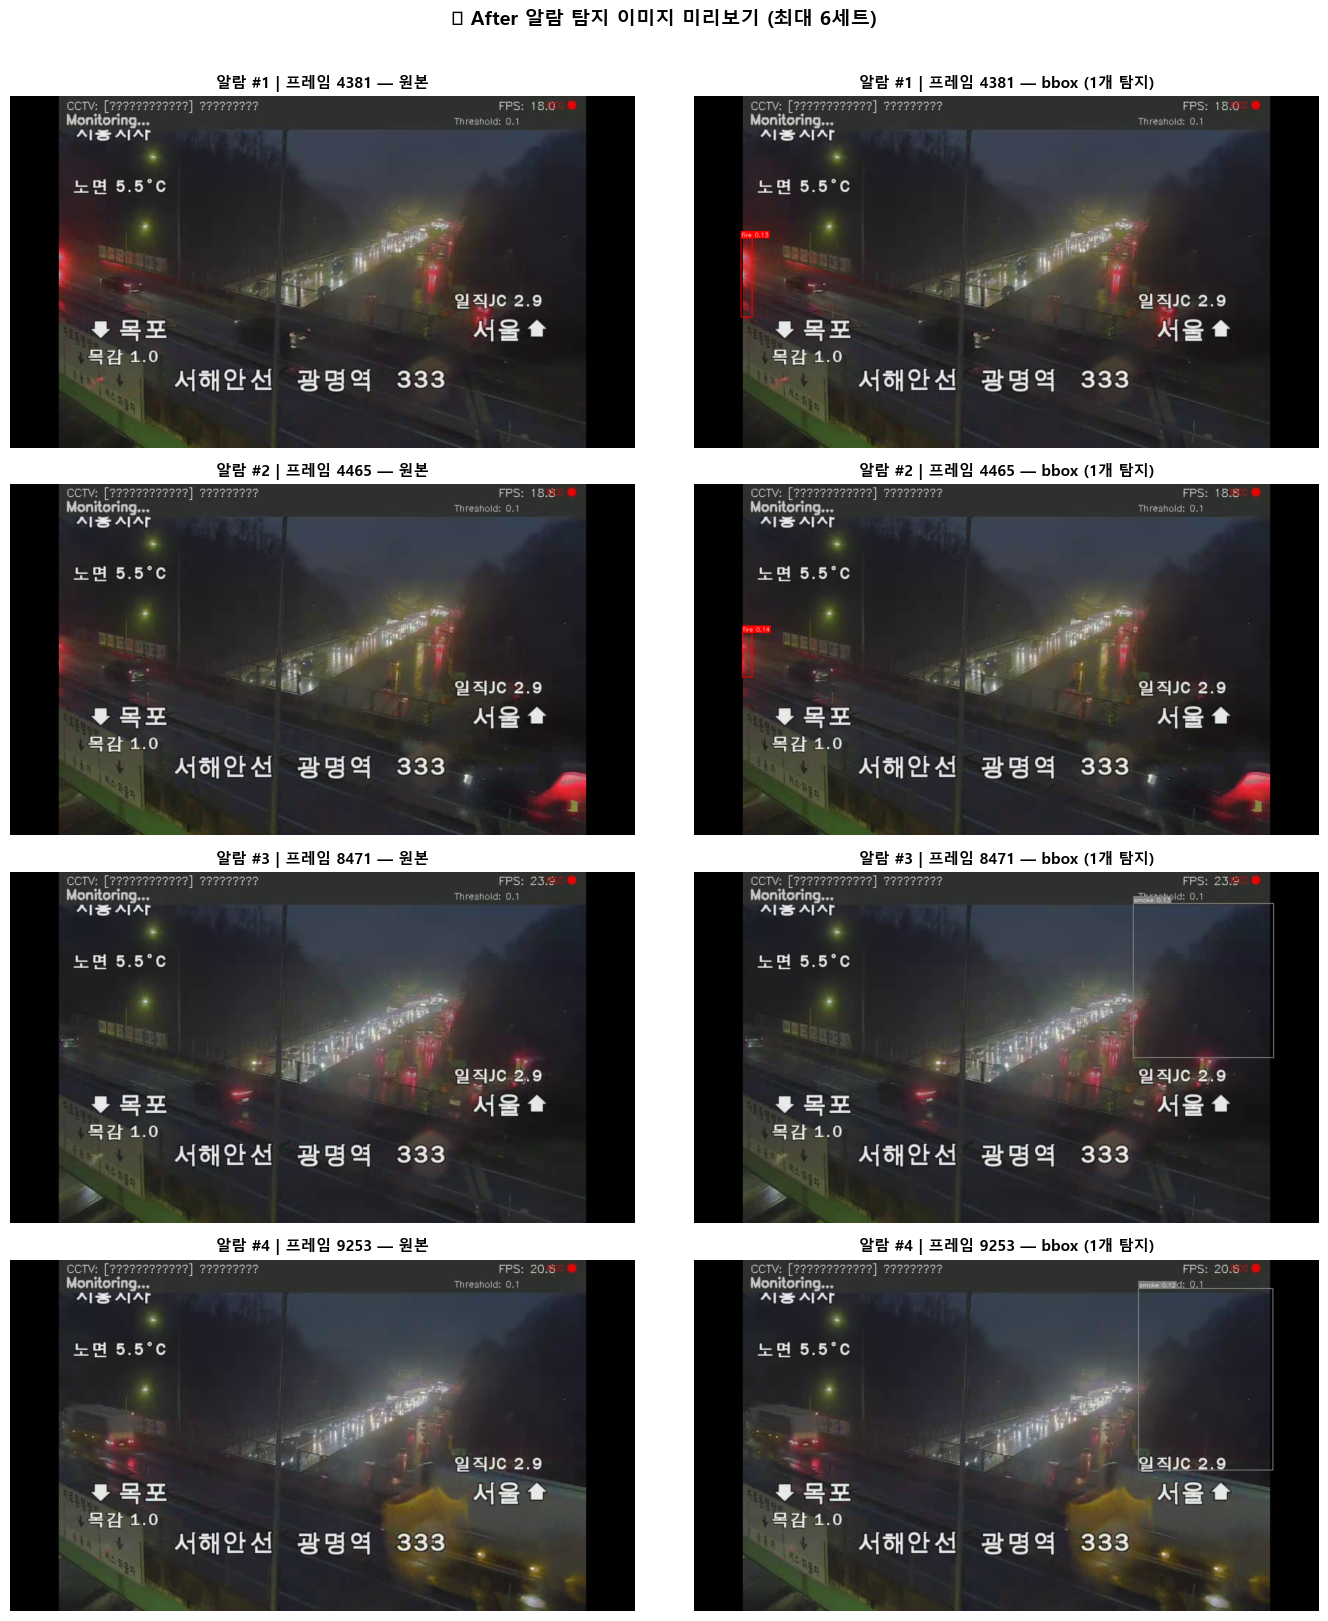


📸 미리보기 저장 완료: N:\개인\이수빈\3.13_Mini_Project\results\temporal_filter_test\after_detection_preview.png


In [20]:
# =============================================================================
# 셀 8-1: After 알람 발생 시점 — 원본 이미지 + bbox 이미지 저장
# =============================================================================
# ★ 이 셀은 셀 8(After 테스트) 바로 다음에 추가
# ★ 이미 선언된 변수: VIDEO_PATH, after_alarms, model, CONF_THRESHOLD,
#                     DEVICE, class_names, SAVE_ROOT

import cv2                                          # OpenCV (영상/이미지 처리)
import numpy as np                                  # 배열 연산
import matplotlib                                   # 시각화 라이브러리
matplotlib.rcParams["font.family"] = "Malgun Gothic" # 한글 폰트 설정 (맑은 고딕)
matplotlib.rcParams["axes.unicode_minus"] = False   # 마이너스 기호 깨짐 방지
import matplotlib.pyplot as plt                     # 그래프/이미지 표시

# ── 0. after_alarms가 비어 있으면 종료 ──────────────────────────────────────
if not after_alarms:                                # 알람이 하나도 없으면
    print("⚠️ after_alarms가 비어 있습니다. 저장할 알람이 없습니다.")  # 안내
    # 아래 코드 실행 안 됨 (셀 종료)
else:
    # ── 1. After 전용 저장 폴더 생성 ────────────────────────────────────────
    SAVE_AFTER_ORIG = SAVE_ROOT / "after_원본"       # After 원본 이미지 폴더
    SAVE_AFTER_BBOX = SAVE_ROOT / "after_bbox"       # After bbox 이미지 폴더
    SAVE_AFTER_ORIG.mkdir(parents=True, exist_ok=True)  # 폴더 없으면 생성
    SAVE_AFTER_BBOX.mkdir(parents=True, exist_ok=True)  # 폴더 없으면 생성
    print(f"📁 After 원본 저장 경로: {SAVE_AFTER_ORIG}")  # 경로 출력
    print(f"📁 After bbox 저장 경로: {SAVE_AFTER_BBOX}")  # 경로 출력

    # ── 2. 각 알람의 start_frame 목록 추출 ──────────────────────────────────
    alarm_frames = []                                # (alarm_id, start_frame) 튜플 리스트
    for alarm in after_alarms:                       # 알람 하나씩 순회
        aid = alarm["alarm_id"]                      # 알람 번호 꺼내기
        sf = alarm["start_frame"]                    # 알람 시작 프레임 번호
        alarm_frames.append((aid, sf))               # 리스트에 추가
    print(f"\n🔍 저장할 알람 수: {len(alarm_frames)}개")  # 총 개수 출력

    # ── 3. 영상 열기 ────────────────────────────────────────────────────────
    cap = cv2.VideoCapture(str(VIDEO_PATH))          # 영상 파일 열기
    if not cap.isOpened():                           # 열기 실패 시
        print(f"❌ 영상을 열 수 없습니다: {VIDEO_PATH}")  # 에러 메시지
    else:
        # ── 4. 클래스별 bbox 색상 정의 ──────────────────────────────────────
        COLOR_MAP = {                                # 클래스명 → BGR 색상
            "fire": (0, 0, 255),                     # 빨간색 (BGR)
            "smoke": (128, 128, 128),                # 회색 (BGR)
        }
        DEFAULT_COLOR = (0, 255, 0)                  # 기본 색상 (초록, 예외용)

        # ── 5. 알람별 프레임 seek → 추론 → 저장 ────────────────────────────
        saved_count = 0                              # 저장 성공 카운터
        preview_pairs = []                           # 미리보기용 (원본, bbox) 리스트

        for aid, frame_idx in alarm_frames:          # 알람 하나씩 처리
            # 5-1. 해당 프레임으로 이동 (전체 루프 없이 바로 점프)
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)  # 프레임 위치 설정
            ret, frame = cap.read()                  # 프레임 읽기
            if not ret:                              # 읽기 실패 시
                print(f"   ⚠️ 알람 #{aid} 프레임 {frame_idx} 읽기 실패, 건너뜀")
                continue                             # 다음 알람으로

            # 5-2. 원본 이미지 저장 (BGR 그대로)
            orig_name = f"after_alarm_{aid:04d}_frame{frame_idx}.jpg"  # 파일명
            orig_path = SAVE_AFTER_ORIG / orig_name  # 전체 경로
            cv2.imwrite(str(orig_path), frame)       # 원본 저장

            # 5-3. YOLO 추론 실행
            results = model.predict(                 # 모델 예측
                source=frame,                        # 입력: 현재 프레임
                conf=CONF_THRESHOLD,                 # 신뢰도 기준
                device=DEVICE,                       # GPU 사용
                verbose=False                        # 로그 숨김
            )

            # 5-4. bbox 그리기 (OpenCV로 직접)
            bbox_frame = frame.copy()                # 원본 복사 (원본 보존)
            boxes = results[0].boxes                 # 탐지된 bbox 목록
            for box in boxes:                        # bbox 하나씩 순회
                # 좌표 추출 (x1, y1, x2, y2)
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)  # 정수 변환
                cls_id = int(box.cls[0].cpu().numpy())    # 클래스 번호 (0 or 1)
                conf = float(box.conf[0].cpu().numpy())   # 신뢰도 (0~1)
                cls_name = class_names.get(cls_id, f"cls_{cls_id}")  # 클래스명 변환
                color = COLOR_MAP.get(cls_name, DEFAULT_COLOR)       # 색상 선택

                # bbox 사각형 그리기
                cv2.rectangle(                       # 사각형 그리기
                    bbox_frame,                      # 대상 이미지
                    (x1, y1), (x2, y2),              # 좌상단, 우하단 좌표
                    color,                           # 선 색상
                    2                                # 선 두께
                )

                # 라벨 텍스트 (클래스명 + 신뢰도)
                label = f"{cls_name} {conf:.2f}"     # 예: "fire 0.85"
                # 텍스트 배경 박스 크기 계산
                (tw, th), _ = cv2.getTextSize(       # 텍스트 크기 측정
                    label,                           # 텍스트 내용
                    cv2.FONT_HERSHEY_SIMPLEX,        # 폰트
                    0.6,                             # 크기
                    1                                # 두께
                )
                # 텍스트 배경 사각형 (가독성용)
                cv2.rectangle(                       # 배경 사각형
                    bbox_frame,                      # 대상 이미지
                    (x1, y1 - th - 8),               # 좌상단 (텍스트 위)
                    (x1 + tw + 4, y1),               # 우하단
                    color,                           # 배경색 = bbox 색상
                    -1                               # -1 = 채우기
                )
                # 텍스트 그리기 (흰색)
                cv2.putText(                         # 텍스트 그리기
                    bbox_frame,                      # 대상 이미지
                    label,                           # 텍스트 내용
                    (x1 + 2, y1 - 4),                # 텍스트 시작 위치
                    cv2.FONT_HERSHEY_SIMPLEX,        # 폰트
                    0.6,                             # 크기
                    (255, 255, 255),                  # 흰색 (BGR)
                    1,                               # 두께
                    cv2.LINE_AA                       # 안티앨리어싱
                )

            # 5-5. bbox 이미지 저장
            bbox_name = f"after_alarm_{aid:04d}_frame{frame_idx}.jpg"  # 파일명
            bbox_path = SAVE_AFTER_BBOX / bbox_name  # 전체 경로
            cv2.imwrite(str(bbox_path), bbox_frame)  # bbox 이미지 저장

            # 5-6. 미리보기용 저장 (최대 6세트)
            if len(preview_pairs) < 6:               # 6개까지만
                preview_pairs.append((                # (원본RGB, bboxRGB, 알람정보) 저장
                    cv2.cvtColor(frame, cv2.COLOR_BGR2RGB),      # BGR→RGB 변환 (원본)
                    cv2.cvtColor(bbox_frame, cv2.COLOR_BGR2RGB), # BGR→RGB 변환 (bbox)
                    aid,                             # 알람 번호
                    frame_idx,                       # 프레임 번호
                    len(boxes)                       # 탐지 개수
                ))

            saved_count += 1                         # 저장 카운터 증가
            print(f"   ✅ 알람 #{aid:04d} | 프레임 {frame_idx} | "
                  f"탐지 {len(boxes)}개 | 저장 완료")  # 진행 상황 출력

        cap.release()                                # 영상 파일 닫기
        print(f"\n{'='*60}")                         # 구분선
        print(f"📊 After 이미지 저장 완료: 총 {saved_count}장 (원본 + bbox)")
        print(f"   📁 원본: {SAVE_AFTER_ORIG}")       # 원본 경로
        print(f"   📁 bbox: {SAVE_AFTER_BBOX}")       # bbox 경로

        # ── 6. matplotlib 미리보기 ──────────────────────────────────────────
        if preview_pairs:                            # 미리보기할 이미지가 있으면
            n_preview = len(preview_pairs)           # 미리보기 개수
            fig, axes = plt.subplots(                # 서브플롯 생성
                n_preview, 2,                        # 행 = 알람 수, 열 = 2 (원본/bbox)
                figsize=(14, 4 * n_preview)          # 전체 크기 (가로 14, 세로 4*행)
            )
            if n_preview == 1:                       # 1행이면 axes가 1D 배열
                axes = axes.reshape(1, -1)           # 2D로 변환 (인덱싱 통일)

            for row, (orig_rgb, bbox_rgb, aid, fidx, det_cnt) in enumerate(preview_pairs):
                # 원본 이미지 표시
                axes[row, 0].imshow(orig_rgb)        # 원본 RGB 표시
                axes[row, 0].set_title(              # 제목 설정
                    f"알람 #{aid} | 프레임 {fidx} — 원본",
                    fontsize=11, fontweight="bold"    # 폰트 크기/굵기
                )
                axes[row, 0].axis("off")             # 축 숨김

                # bbox 이미지 표시
                axes[row, 1].imshow(bbox_rgb)        # bbox RGB 표시
                axes[row, 1].set_title(              # 제목 설정
                    f"알람 #{aid} | 프레임 {fidx} — bbox ({det_cnt}개 탐지)",
                    fontsize=11, fontweight="bold"    # 폰트 크기/굵기
                )
                axes[row, 1].axis("off")             # 축 숨김

            plt.suptitle(                            # 전체 제목
                f"🟢 After 알람 탐지 이미지 미리보기 (최대 6세트)",
                fontsize=14, fontweight="bold",       # 폰트 설정
                y=1.01                                # 제목 위치 (위로)
            )
            plt.tight_layout()                       # 레이아웃 자동 조정

            # 미리보기 이미지 파일로 저장
            preview_path = SAVE_ROOT / "after_detection_preview.png"  # 저장 경로
            fig.savefig(                             # 파일로 저장
                str(preview_path),                   # 경로
                dpi=150,                             # 해상도
                bbox_inches="tight",                 # 여백 자동 조절
                facecolor="white"                    # 배경 흰색
            )
            plt.show()                               # 화면에 표시
            print(f"\n📸 미리보기 저장 완료: {preview_path}")  # 경로 출력
        else:                                        # 미리보기할 이미지 없으면
            print("⚠️ 미리보기할 이미지가 없습니다.")  # 안내

In [21]:
# =============================================================================
# 셀 9: 결과 비교 + JSON 저장
# =============================================================================

# Before 이벤트 수 (연속 탐지를 하나의 이벤트로)
before_events = []
in_evt = False
for i, detected in enumerate(before_frame_results):
    if detected and not in_evt:
        in_evt = True
        time_sec = i / fps if fps > 0 else 0
        before_events.append({"start_frame": i, "time_sec": round(time_sec, 2)})
    elif not detected:
        in_evt = False

before_count = len(before_events)
after_count = len(after_alarms)
reduction = (1 - after_count / before_count) * 100 if before_count > 0 else 0

# 결과 출력
print()
print("=" * 50)
print("  연속 프레임 필터 효과 검증 결과")
print("=" * 50)
print(f"  Before (필터 없음)       : 탐지 {before_count}회")
print(f"  After  ({CONSECUTIVE_FRAMES}프레임 필터)    : 탐지 {after_count}회")
print(f"  감소율                  : {reduction:.1f}%")
print("=" * 50)

print(f"\n📋 상세:")
print(f"  총 프레임: {len(before_frame_results):,}")
print(f"  탐지 프레임: {sum(before_frame_results):,} ({sum(before_frame_results)/len(before_frame_results)*100:.2f}%)")
print(f"  Before 이벤트: {before_count}회")
print(f"  After 알람: {after_count}회")
print(f"  제거된 오탐: {before_count - after_count}회")
print(f"  저장된 이미지: {saved_count}세트")

# ★ JSON 저장
summary = {
    "test_info": {
        "model": "YOLOv8n_tuned",
        "threshold": CONF_THRESHOLD,
        "consecutive_frames": CONSECUTIVE_FRAMES,
        "video": str(VIDEO_PATH.name),
        "total_frames": len(before_frame_results),
        "fps": fps
    },
    "before": {
        "detection_frames": len(before_detections),
        "events": before_count,
        "fire_frames": total_fire,
        "smoke_frames": total_smoke,
        "both_frames": total_both
    },
    "after": {
        "alarms": after_count,
        "fire_alarms": fire_events,
        "smoke_alarms": smoke_events
    },
    "comparison": {
        "reduction_rate": round(reduction, 1),
        "removed_false_positives": before_count - after_count
    },
    "saved_images": saved_count
}

json_path = SAVE_ROOT / "filter_summary.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print(f"\n💾 요약 저장: {json_path}")



  연속 프레임 필터 효과 검증 결과
  Before (필터 없음)       : 탐지 66회
  After  (10프레임 필터)    : 탐지 4회
  감소율                  : 93.9%

📋 상세:
  총 프레임: 37,434
  탐지 프레임: 218 (0.58%)
  Before 이벤트: 66회
  After 알람: 4회
  제거된 오탐: 62회
  저장된 이미지: 4세트

💾 요약 저장: N:\개인\이수빈\3.13_Mini_Project\results\temporal_filter_test\filter_summary.json


C:\Users\User\AppData\Local\Temp\ipykernel_24500\3455087687.py:60: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_24500\3455087687.py:60: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_24500\3455087687.py:60: UserWarning: Glyph 128168 (\N{DASH SYMBOL}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_24500\3455087687.py:60: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_24500\3455087687.py:60: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_24500\3455087687.py:60: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) Malgun Gothic

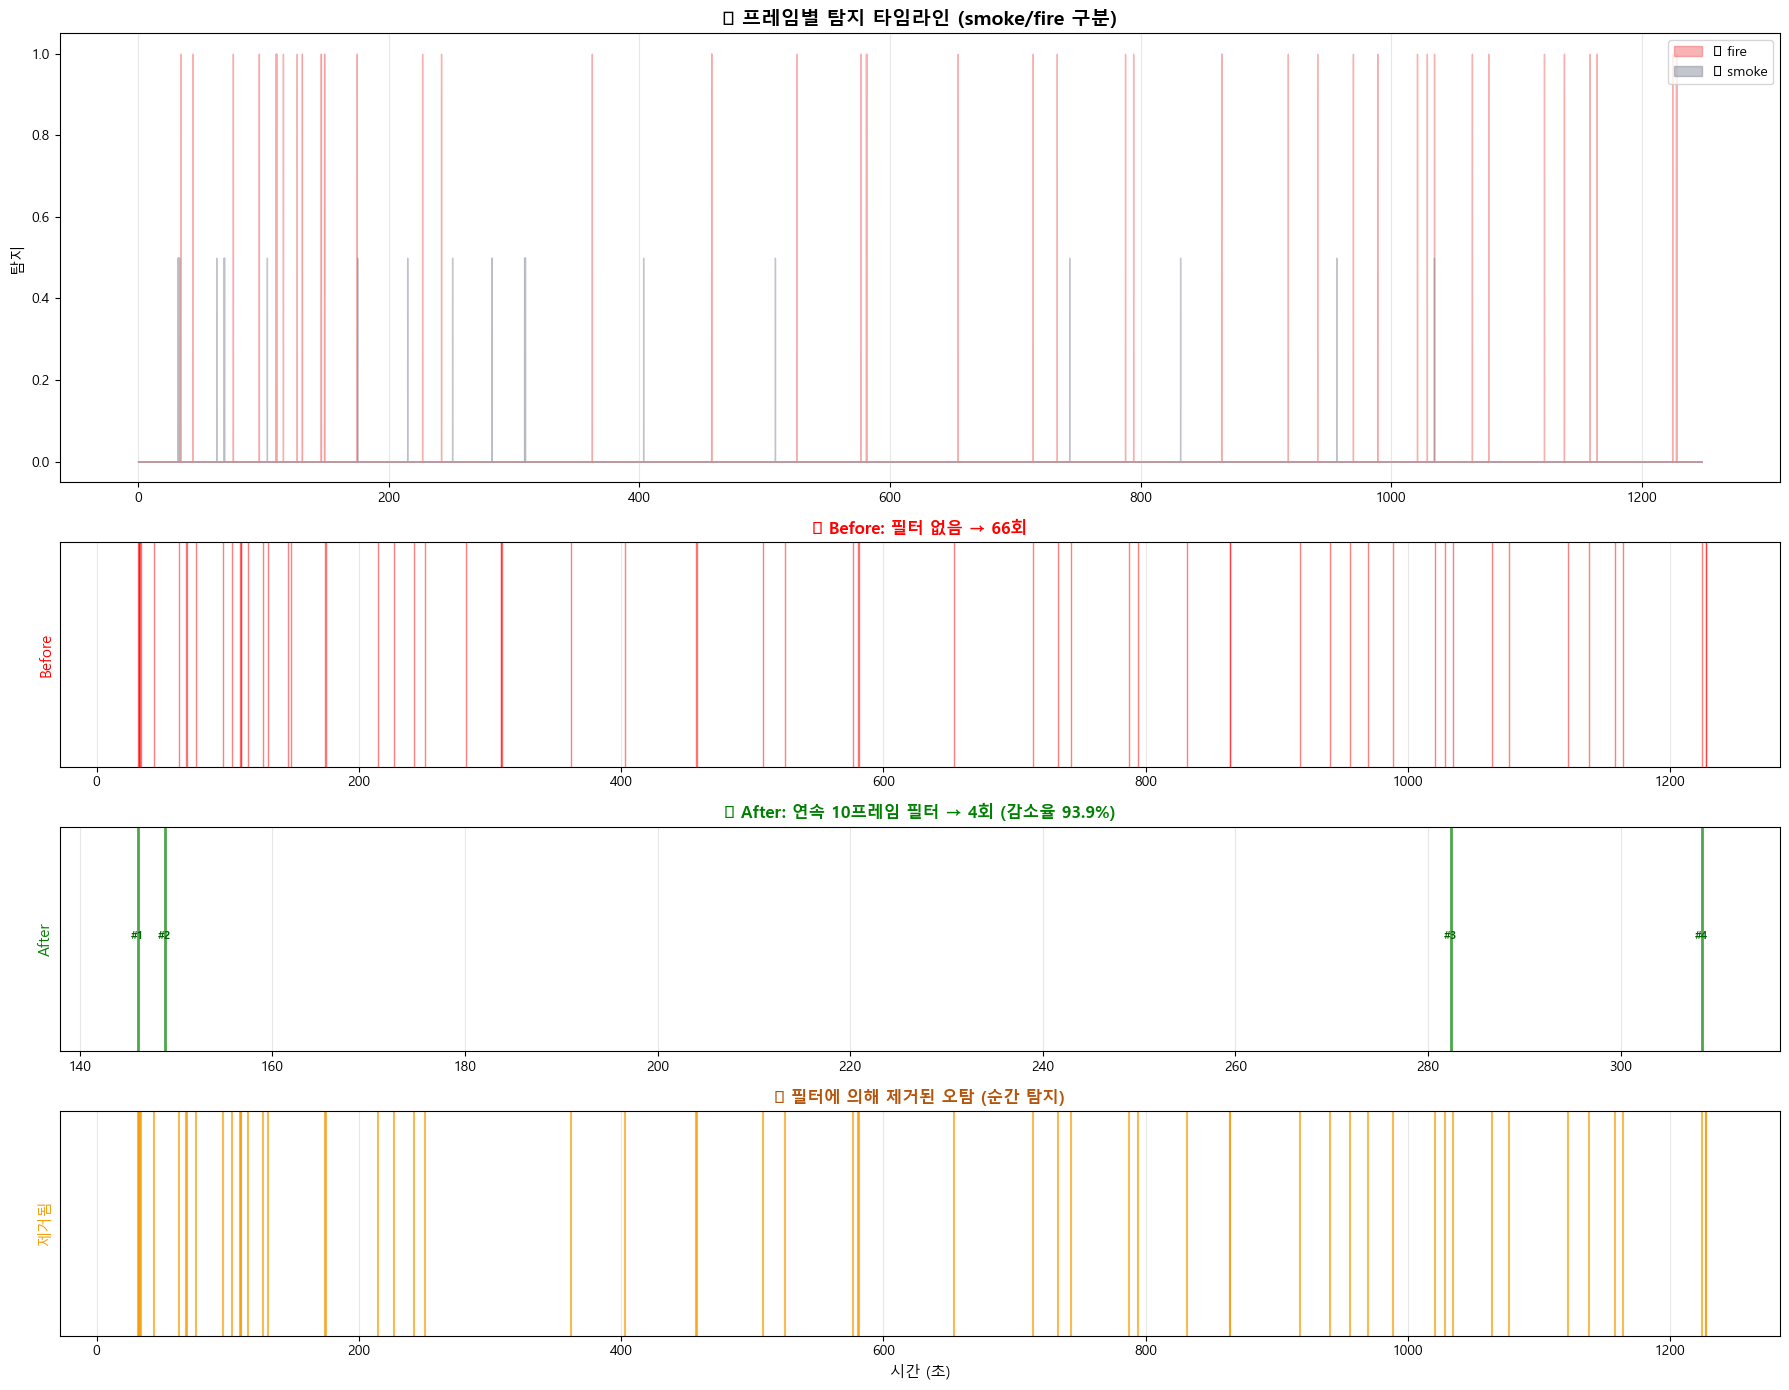


💾 저장: N:\개인\이수빈\3.13_Mini_Project\results\temporal_filter_test\temporal_filter_timeline.png


In [22]:
# =============================================================================
# 셀 10: 타임라인 시각화
# =============================================================================

fig, axes = plt.subplots(4, 1, figsize=(18, 14),
                         gridspec_kw={"height_ratios": [2, 1, 1, 1]})

time_axis = np.arange(len(before_frame_results)) / fps

# ─── 1행: 전체 탐지 타임라인 (smoke/fire 색상 구분) ───
ax1 = axes[0]
fire_vals = []               # fire 탐지 시 1, 아니면 0
smoke_vals = []              # smoke 탐지 시 1, 아니면 0
for classes in before_frame_classes:
    fire_vals.append(1 if "fire" in classes else 0)
    smoke_vals.append(0.5 if "smoke" in classes else 0)  # 0.5로 구분

ax1.fill_between(time_axis, fire_vals, alpha=0.4, color="#ef4444", label="🔥 fire")
ax1.fill_between(time_axis, smoke_vals, alpha=0.4, color="#6b7280", label="💨 smoke")
ax1.set_ylabel("탐지", fontsize=11)
ax1.set_title("🎬 프레임별 탐지 타임라인 (smoke/fire 구분)", fontsize=14, fontweight="bold")
ax1.legend(loc="upper right", fontsize=10)
ax1.grid(axis="x", alpha=0.3)

# ─── 2행: Before (필터 없음) ───
ax2 = axes[1]
for event in before_events:
    ax2.axvline(x=event["time_sec"], color="red", alpha=0.5, linewidth=1)
ax2.set_ylabel("Before", fontsize=11, color="red")
ax2.set_title(f"🔴 Before: 필터 없음 → {before_count}회", fontsize=12, fontweight="bold", color="red")
ax2.set_yticks([])
ax2.grid(axis="x", alpha=0.3)

# ─── 3행: After (필터 적용) ───
ax3 = axes[2]
for alarm in after_alarms:
    ax3.axvline(x=alarm["time_sec"], color="green", alpha=0.7, linewidth=2)
    ax3.annotate(f'#{alarm["alarm_id"]}', xy=(alarm["time_sec"], 0.5),
                fontsize=8, ha="center", color="darkgreen", fontweight="bold")
ax3.set_ylabel("After", fontsize=11, color="green")
ax3.set_title(f"🟢 After: 연속 {CONSECUTIVE_FRAMES}프레임 필터 → {after_count}회 (감소율 {reduction:.1f}%)",
              fontsize=12, fontweight="bold", color="green")
ax3.set_yticks([])
ax3.grid(axis="x", alpha=0.3)

# ─── 4행: 제거된 오탐 (Before에만 있고 After에 없는 것) ───
ax4 = axes[3]
after_times = set(a["time_sec"] for a in after_alarms)
for event in before_events:
    # After 알람과 10초 이내에 매칭되는지 확인
    matched = any(abs(event["time_sec"] - at) < 10 for at in after_times)
    if not matched:          # After에 없는 것 = 제거된 오탐
        ax4.axvline(x=event["time_sec"], color="#f59e0b", alpha=0.7, linewidth=1.5)
ax4.set_ylabel("제거됨", fontsize=11, color="#f59e0b")
ax4.set_title(f"🟡 필터에 의해 제거된 오탐 (순간 탐지)", fontsize=12, fontweight="bold", color="#b45309")
ax4.set_yticks([])
ax4.set_xlabel("시간 (초)", fontsize=11)
ax4.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(str(SAVE_ROOT / "temporal_filter_timeline.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"\n💾 저장: {SAVE_ROOT / 'temporal_filter_timeline.png'}")


🔬 다양한 연속 프레임 수별 비교
  연속  1프레임 | 알람  66회 | 감소율   0.0% | 지연 0.03초
  연속  3프레임 | 알람  23회 | 감소율  65.2% | 지연 0.10초
  연속  5프레임 | 알람  10회 | 감소율  84.8% | 지연 0.17초
  연속  7프레임 | 알람   7회 | 감소율  89.4% | 지연 0.23초
  연속 10프레임 | 알람   4회 | 감소율  93.9% | 지연 0.33초 ★ 현재
  연속 15프레임 | 알람   0회 | 감소율 100.0% | 지연 0.50초
  연속 30프레임 | 알람   0회 | 감소율 100.0% | 지연 1.00초


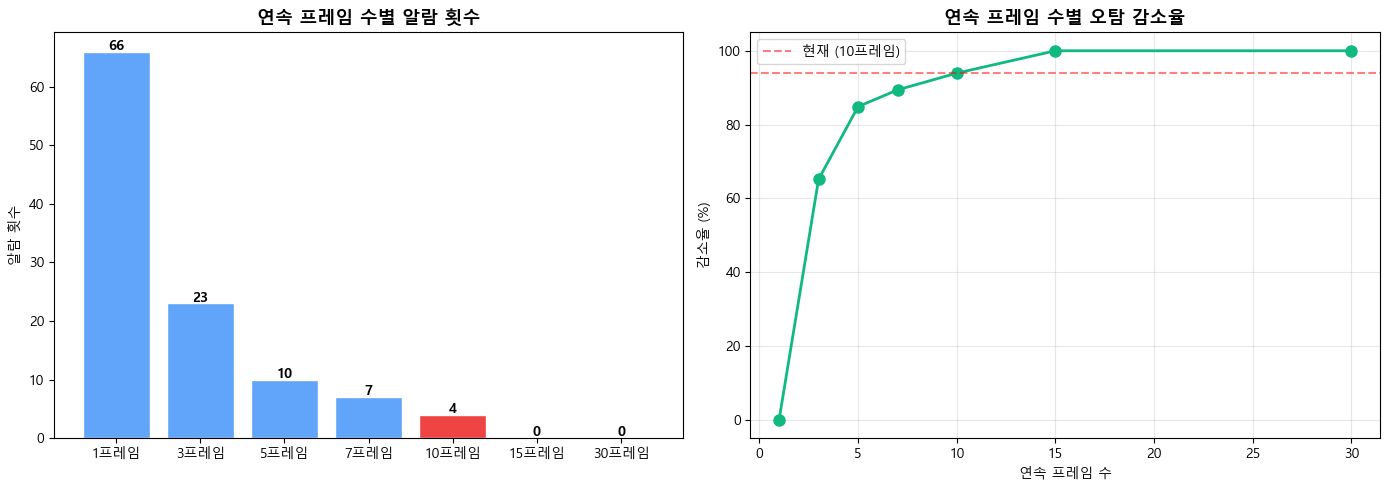


💾 저장: N:\개인\이수빈\3.13_Mini_Project\results\temporal_filter_test\frame_threshold_comparison.png


In [23]:
# =============================================================================
# 셀 11: 다양한 연속 프레임 수별 비교
# =============================================================================

print("=" * 60)
print("🔬 다양한 연속 프레임 수별 비교")
print("=" * 60)

test_thresholds = [1, 3, 5, 7, 10, 15, 30]         # 비교할 프레임 수
comparison_results = []

for n_frames in test_thresholds:
    count = 0
    active = False
    alarm_count = 0

    for detected in before_frame_results:
        if detected:
            count += 1
        else:
            count = 0
            active = False
        if count >= n_frames and not active:
            active = True
            alarm_count += 1

    red = (1 - alarm_count / before_count) * 100 if before_count > 0 else 0
    delay = n_frames / fps if fps > 0 else 0
    comparison_results.append({"frames": n_frames, "alarms": alarm_count,
                               "reduction": red, "delay": delay})

    marker = " ★ 현재" if n_frames == CONSECUTIVE_FRAMES else ""
    print(f"  연속 {n_frames:>2}프레임 | 알람 {alarm_count:>3}회 | "
          f"감소율 {red:>5.1f}% | 지연 {delay:.2f}초{marker}")

# 그래프
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

frames_list = [r["frames"] for r in comparison_results]
alarms_list = [r["alarms"] for r in comparison_results]
colors = ["#ef4444" if f == CONSECUTIVE_FRAMES else "#60a5fa" for f in frames_list]

ax1.bar(range(len(frames_list)), alarms_list, color=colors, edgecolor="white")
ax1.set_xticks(range(len(frames_list)))
ax1.set_xticklabels([f"{f}프레임" for f in frames_list])
ax1.set_ylabel("알람 횟수")
ax1.set_title("연속 프레임 수별 알람 횟수", fontsize=13, fontweight="bold")
for i, v in enumerate(alarms_list):
    ax1.text(i, v + 0.3, str(v), ha="center", fontweight="bold")

reductions = [r["reduction"] for r in comparison_results]
ax2.plot(frames_list, reductions, marker="o", color="#10b981", linewidth=2, markersize=8)
current_idx = frames_list.index(CONSECUTIVE_FRAMES)
ax2.axhline(y=reductions[current_idx], color="red", linestyle="--", alpha=0.5,
            label=f"현재 ({CONSECUTIVE_FRAMES}프레임)")
ax2.set_xlabel("연속 프레임 수")
ax2.set_ylabel("감소율 (%)")
ax2.set_title("연속 프레임 수별 오탐 감소율", fontsize=13, fontweight="bold")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(SAVE_ROOT / "frame_threshold_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"\n💾 저장: {SAVE_ROOT / 'frame_threshold_comparison.png'}")


## 🏁 최종 결론

### 산출물 목록
| 파일/폴더 | 설명 |
|-----------|------|
| `원본/` | 탐지 이벤트 시작 시점의 원본 이미지 |
| `bbox/` | 같은 시점의 바운딩박스 이미지 (뭘 오탐했는지 확인) |
| `before_detections.csv` | Before 전체 탐지 기록 (프레임, 시간, 클래스) |
| `after_alarms.csv` | After 알람 기록 (프레임, 시간, 연속프레임수, 클래스) |
| `filter_summary.json` | Before/After 비교 요약 + 클래스별 통계 |
| `temporal_filter_timeline.png` | 4행 타임라인 (전체/Before/After/제거된오탐) |
| `frame_threshold_comparison.png` | 1/3/5/7/10/15/30 프레임별 비교 |
| `class_distribution.png` | smoke/fire 파이 차트 |
| `detection_preview.png` | 원본+bbox 미리보기 (처음 8세트) |

### 10프레임으로 바꾸고 싶다면?
셀 2의 이 한 줄만 바꾸세요:
```python
CONSECUTIVE_FRAMES = 10    # 5 → 10으로 변경
```
그리고 **셀 2부터 다시 실행** (셀 5 Before 테스트는 다시 안 돌려도 됨 — After부터만 다시 실행하면 됨)
